Names: Saahir Tandon

# **DATA SCIENCE COMPONENT:**

#### **1. DATA COLLECTION (Imported from Kaggle)**

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# Gets the path of the dataset in the repo
data_path = Path("data") / "student-mat.csv"



# Reads the dataset
df = pd.read_csv(data_path, sep=";")



# Get a summary of the dataset
print("This is a summary of the original dataset:")
print("\n")
print(df.head())

This is a summary of the original dataset:


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


#### **2. DATA CLEANING (Missing Values, Converting Categorical to Numerical, and Outliers)**

In [91]:
# Get rid of columns that we don't need
df = df.drop(columns=['school', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'health'], errors='ignore')

# Get a summary of the dataset after dropping irrelevant columns
print("This is a summary of the dataset after dropping columns we won't use:")
print("\n")
print(df.head())

This is a summary of the dataset after dropping columns we won't use:


  sex  age  studytime  failures schoolsup famsup  goout  Dalc  Walc  absences  \
0   F   18          2         0       yes     no      4     1     1         6   
1   F   17          2         0        no    yes      3     1     1         4   
2   F   15          2         3       yes     no      2     2     3        10   
3   F   15          3         0        no    yes      2     1     1         2   
4   F   16          2         0        no    yes      2     1     2         4   

   G1  G2  G3  
0   5   6   6  
1   5   5   6  
2   7   8  10  
3  15  14  15  
4   6  10  10  


In [92]:
# Check for null values in each column
print("This table shows all the missing values in each column:")
print("\n")
print(df.isnull().sum())

This table shows all the missing values in each column:


sex          0
age          0
studytime    0
failures     0
schoolsup    0
famsup       0
goout        0
Dalc         0
Walc         0
absences     0
G1           0
G2           0
G3           0
dtype: int64


This table shows us that there are no missing values to handle.

In [93]:
# See all columns and their datatypes -- to identify which ones need to be changed
print("These are the datatypes for each column:")
print("\n")
print(df.dtypes)

These are the datatypes for each column:


sex          object
age           int64
studytime     int64
failures      int64
schoolsup    object
famsup       object
goout         int64
Dalc          int64
Walc          int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


In [76]:
# Change columns' datatype from object to numerical for easier model training later
df['sex'] = df['sex'].map({'M': 1, 'F': 0})
df['schoolsup'] = df['schoolsup'].map({'yes': 1, 'no': 0})
df['famsup'] = df['famsup'].map({'yes': 1, 'no': 0})

# Check the datatypes of all columns were updated
print("These are the datatypes for each column after updating:")
print("\n")
print(df.dtypes)

These are the datatypes for each column after updating:


sex          int64
age          int64
studytime    int64
failures     int64
schoolsup    int64
famsup       int64
goout        int64
Dalc         int64
Walc         int64
absences     int64
G1           int64
G2           int64
G3           int64
dtype: object


In [ ]:
# Visualize each column in the dataset (before removing outliers)
check_outliers = ['age', 'studytime', 'failures', 'goout', 'Dalc', 'Walc', 'absences', 'G1', 'G2']

for column in check_outliers:

  sns.boxplot(x=df[column])
  plt.title(f"{column} Before Removing Outliers")
  plt.show()

The boxplot for age before removing outliers shows that most students fall with the range of 16 and 18 years old -- this makes sense since this dataset is based on high school students. The median age is 17. There is a noticable outlier at age 22 which is way past the upper whisker. Given their age, this is likely a student who has failed school many times and keeps repeating over and over again. It is important to remove this student as they are likely a many-times failing student who will skew the model.


The boxplot for studytime before removing outliers shows that most students study between 1 and 2 hours with the median being 1.5 hours. There is an outliier at 0 hours below the lower whisker -- which means there is a student that doesn't study for any hours outside of school. It is important to remove this outlier has someone who doesn't study likley is a failing student which will skew the model.


The boxplot for failures before removing outliers shows that nearly all students have failed 0 classes before. Because of this tight conectration, any student with even 1 or 2 failures are outliers. This imbalance can negatively influence the model by making faiilures appear more extreme than they statistically are, so it is important to remove them.


The boxplot for goout before removing outliers shows that most students fall within the range of 2 and 4 -- which means most students go out between 2 and 4 times in a week. The median is at 3. The whisker spread to 1 and 5 (the min and max) and there are no outliers noticable to clean.


The boxplot for Dalc before removing outliers shows most students are within 1 and 2 -- which means most students drink alcohol 1 to 2 times on the week (weekdays only). The median is close to 1. There are a few outliers at 4 and 5. These students are drinking much more than the average student and intoxication leads to impaired thinking which can lead to worse performance at school -- so it is important to remove these outliers.


The boxplot for Walc before removing outliers shows that most students drink on the weekend between 1 and 3 times with the median at 2. There are no outliers to clean.


The boxplot for absences before removing outliers shows that most students have missed between 0 and 10 classes with a median around 5. There are many outliers past the upper whisker at 20. Small groups of students have missed a large number of classes -- and it is important to clean these extreme outliers. The more you miss class it is likely the worse you will do.


The boxplot for G1 before removing outliers shows a balanced distribution with most students having a period 1 grade between 8 and 13 with the median at 11. There are no outliers to clean.


The boxplot for G2 before removing outliers shows that most students have a second period grade between 9 and 13 with a median at 11. There is an outlier below the lower whisker at 0 which means a student has a failing second period grade which likely instantly lead to a failing final grade -- so it is important to cleant this.

In [95]:
# Remove outliers for all numeric columns
cleaned = df.copy()

for column in check_outliers:
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  cleaned = cleaned[(cleaned[column] >= lower_bound) & (cleaned[column] <= upper_bound)]

In [ ]:
# Visualize each column in the dataset (after removing outliers)
for column in check_outliers:
  sns.boxplot(x=cleaned[column])
  plt.title(f"{column} After Removing Outliers")
  plt.show()

For the features that had no outliers like goout, the boxplots have not changed after removing outliers. Most of the features had just a couple outliers so they now look a lot better distributed with no more outliers -- like G2. The features like failures the distribution has become more compact and the whiskers shrunk. It was imperative to remove all those outliers as they may have caused skewness and influenced the model too strongly -- since they could've been very correlated with final grade.

#### **3. DATA VISUALIZATION**

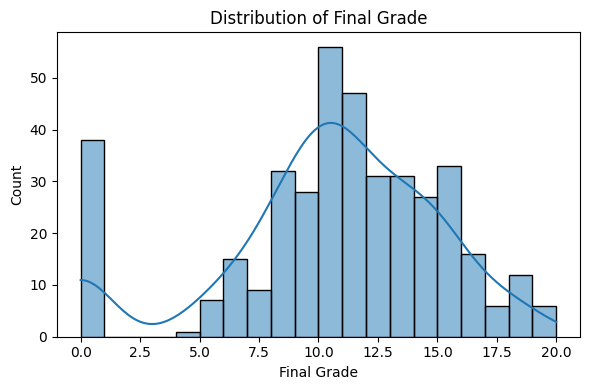

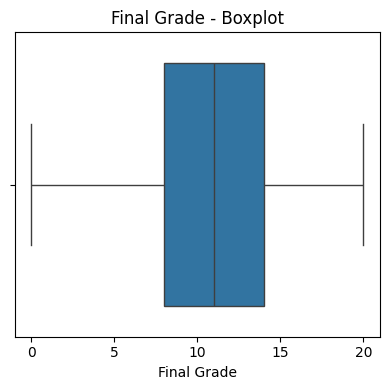

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [97]:
# Histogram of final grade
plt.figure(figsize=(6,4))
sns.histplot(df["G3"], kde=True, binwidth=1)  # or discrete=True in newer seaborn
plt.title("Distribution of Final Grade")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



# Boxplot of final grade
plt.figure(figsize=(4,4))
sns.boxplot(x=df["G3"])
plt.title("Final Grade - Boxplot")
plt.xlabel("Final Grade")
plt.tight_layout()
plt.show()



# Summary of Final Grade
df["G3"].describe()

I visualized G3 (Final Grade) because I am making that the target thatn we will try to predict. The histogram and boxplot will help me determine what exactly about Final Grade will I predict: range, average value, spread, outliers, pass/fail, etc. It wll help me determine this buy providing a clear visual about the center, spread, shape, and outliers of the final grade distribution.


From the summary statistics, there are a total of 395 students. The mean final grade iis about 10.4. The median final grade is 11. The minimum final grade is 0 and the maximum final grade is 20. This tells us that grades span from 0 to 20.


The boxplot shows that IQR (middle 50% of students) have grades between 8 and 14, whiich means half of all students are getting grades in this range. This also tells us that majority of the students have a final grade that puts them on the edge of passing and failing; since the max grade is 20 we know all grades are out of 20 which means that a passing grade (around 60%) is a 12/20. This validates the purpose of my project as by identfying these students who are failing (which is a good amount), academic institutions can provide help to push these students just a little bit to make them passing students.

The histogram is mostly bell-shaped (looking at the line of best fit) wth the major deviation being at final grades less than 2.5. This tells us that aside from 50% of students being on the border of passinig and failinig, the next peak of students are at failing grades -- which furthers the purpose of the project. The mode is around 11/12 -- supportinig the boxplot that many students are on the border of failing and passing. Overall, the distribution is symmetric with no strong skews -- this suggests that linear regression might be better than non linear because it will be reasonable to model fnal grade as a continuous numeric outcome.



Based on the visualization, we see that Final Grade ranges from 0 to 20 -- where most students are around 11, but there is a wide spread with other modes at 8 and 16. In other words, there are chunks of low scores (fails) and high ones (pass). Becuase of this we will use a regression model to predict the exact numerical Final Grade. Essentially, since all students don't have the same Final Grade there is a point to predicting their final grade -- we can determine which students might need  help and contribute to their academic success.

#### **4. SAVE THE CLEANED DATA**

In [98]:
cleaned.to_csv("student-mat-cleaned.csv", index=False)

# **DATABASE/SQL COMPONENT:**

#### **Setup SQLite**

In [99]:
import sqlite3

db_path = Path("student_performance.db")

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

def run_sql(sql, params=None, show=True):
    """Run a SQL command (or multiple commands) and optionally show results as a DataFrame."""
    if params is None:
        params = ()
    try:
        cursor.executescript(sql) if "\n" in sql.strip().split(" ")[0] else cursor.execute(sql, params)
        conn.commit()
        if show and sql.lstrip().lower().startswith("select"):
            rows = cursor.fetchall()
            cols = [desc[0] for desc in cursor.description]
            display(pd.DataFrame(rows, columns=cols))
    except Exception as e:
        print("Error:", e)

print("Connected to:", db_path.resolve())

Connected to: /home/st1225/cs210f25/Course Project - Final Report/student_performance.db


#### **Load the Cleaned Data Set**

In [100]:
# Gets the path of the current working directory
cwd = os.getcwd()



# Saves the path as a Path object
cwd_path = Path(cwd)



# Gets the path of the cleaned dataset in the cwd
cleaned_data = cwd_path / "student-mat-cleaned.csv"



# Reads the cleaned dataset
df = pd.read_csv(cleaned_data, sep=",")

#### **Create empty SQL table**

In [101]:
create_raw_sql = """
DROP TABLE IF EXISTS StudentPerformance;

CREATE TABLE StudentPerformance (
  StudentID INTEGER PRIMARY KEY AUTOINCREMENT,
  sex INTEGER,
  age INTEGER,
  studytime INTEGER,
  failures INTEGER,
  schoolsup INTEGER,
  famsup INTEGER,
  goout INTEGER,
  Dalc INTEGER,
  Walc INTEGER,
  absences INTEGER,
  G1 INTEGER,
  G2 INTEGER,
  G3 INTEGER
);
"""

parts = create_raw_sql.split(";")

for statement in parts:
    new_statement = statement.strip()

    if new_statement:
        run_sql(new_statement, show=False)


print("StudentPerformance table created.")

StudentPerformance table created.


#### **Fill SQL table with Cleaned Data Set**

In [102]:
df.to_sql("StudentPerformance", conn, if_exists="replace", index=False)


print("Loaded data into StudentPerformance.")


# Previews the first 5 rows
run_sql("SELECT * FROM StudentPerformance LIMIT 5;")

Loaded data into StudentPerformance.


,sex,age,studytime,failures,schoolsup,famsup,goout,Dalc,Walc,absences,G1,G2,G3
0,F,18,2,0,yes,no,4,1,1,6,5,6,6
1,F,17,2,0,no,yes,3,1,1,4,5,5,6
2,F,15,3,0,no,yes,2,1,1,2,15,14,15
3,F,16,2,0,no,yes,2,1,2,4,6,10,10
4,M,16,2,0,no,yes,2,1,2,10,15,15,15


#### **Query 1: What is the average final grade?**

In [103]:
run_sql("""
SELECT AVG(G3) AS AverageFinalGrade
FROM StudentPerformance;
""")

,AverageFinalGrade
0,11.662791


The average final grade of 11.7 helps us establish a baseline performance level for all students, which will also give us more context for the other queries we make.

#### **Query 2: How many students pass vs fail?**

In [104]:
run_sql("""
SELECT SUM(CASE WHEN G3 >= 10 THEN 1 ELSE 0 END) AS PassingStudents, SUM(CASE WHEN G3 < 10 THEN 1 ELSE 0 END) AS FailingStudents
FROM StudentPerformance;
""")

print("\n")
print(f"The total number of students is: {len(df)}")

print("\n")
print(f"The percentage of students who passed is: {204/258 * 100}")

print("\n")
print(f"The percentage of students who failed is: {54/258 * 100}")

,PassingStudents,FailingStudents
0,204,54




The total number of students is: 258


The percentage of students who passed is: 79.06976744186046


The percentage of students who failed is: 20.930232558139537


Out of the 258 students in the dataset, 204 students (79.1%) got a passing final grade (G3 >= 10), while 54 students (20.9%) got a failing final grade (G3 < 10).

This shows that the majority of students do pass, however, a noticeable chunk still struggle (close to a fourth).

Thus, understanding the characteristics of the failing students can help inform the ML model later.

#### **Query 3: Does study time affect performance?**

In [105]:
run_sql("""
SELECT studytime, AVG(G3) AS AvgG3
FROM StudentPerformance
GROUP BY studytime
ORDER BY studytime;
""")

,studytime,AvgG3
0,1,12.151515
1,2,11.128571
2,3,12.480769


In this dataset:
studytime=1 means the student studied for less than 2 hours per week
studytime = 2 means the student studied between 2 and 5 hours per week
studytime = 3 means the student studied between 5 and 10 hours per week
studytime = 4 means the student studied more than 10 hours per week


Since we cleaned the dataset for outliers, we no longer have the few students with studytime=4


Students with studytime=1 have average final grade of 12.2
Students with studytime=2 have average final grade of 11.1
Students with studytime=3 have average final grade of 12.5


In order of highest to lowest, studytime leves are ranked as: 3, 1, 2.


Students with studytime=1 and studytime=3 have average final grade greater than the average final grade of 11.7. Students with studytime=2 have average final grade less than the average final grade of 11.7


Generally, one would assume the more you study the better grade you'll get. However, studytime=2 defies this logic in all the above metrics. This tells us that studytime doesn't impact final grade as much as we may assume and other features may have a stronger correlation (it still impacts in general).

#### **Query 4: Do absences correlate with lower grades?**

In [106]:
run_sql("""
SELECT absences, AVG(G3) AS AvgG3
FROM StudentPerformance
GROUP BY absences
ORDER BY absences;
""")

,absences,AvgG3
0,0,11.541667
1,1,13.500000
2,2,12.368421
3,3,12.333333
4,4,11.243902
5,5,12.750000
6,6,11.470588
7,7,11.600000
8,8,11.500000
9,9,13.333333


The relationship between absences and final grade (G3) shows a generally negative trend. Students with higher numbers of absences tend to perform worse on average. However, because some absence levels have very few students, certain averages appear unusually high or low (e.g., absences = 13). Overall, the results support the expectation that consistent attendance is associated with better academic performance, which is relevant for the ML model.

#### **Query 5: Which students have more than 50% estimated attendance?**

In [107]:
run_sql("""
SELECT COUNT(*) AS StudentsAbove50
FROM (
    SELECT *,
        1 - (absences * 1.0 / (SELECT MAX(absences) FROM StudentPerformance)) AS AttendanceRate
    FROM StudentPerformance
)
WHERE AttendanceRate > 0.50;
""")

,StudentsAbove50
0,221


The data set doesn't actually contain an attendance column, so I estimated the attendance using the absences column.

I said that the AttendanceRate = 1 - (absences / max(absences))

This makes it so that students with 0 absences are marked with an attendance rate of 1 whereas students with the max absences are marked with an attendance rate of 0. All other students fall in between 0 and 1. The closer to 0, the better the attendance (since you have less absences). The closer to 1, the worse the attendance (since you have more absences).

From there I use a simple query that counts the total number of stuents who have an attendance rate greater than 0.5 because this will tell us how many studnets miss class less often than half the maxiumum absence rate.

This statistic helps us evaluate student engagement levels and may suggest that attendance is directly related to final grade -- which will be useful for our model.

The query tells us that 221 students have attendance above 50%. This suggests that most students attend class regularly, which presumably aligns with our past discovery that the average final grade is pretty high. In other words, we can confirm our suspicion that the better the attendance, the better the final grade.

#### **Query 6: Does having prior failiures impact final grade?**

In [108]:
run_sql("""
SELECT failures, AVG(G3) AS AvgG3
FROM StudentPerformance
GROUP BY failures
ORDER BY failures;
""")

,failures,AvgG3
0,0,11.662791


The Math dataset used in this project contains only students with zero prior class failures. As a result, the average G3 is identical across the entire dataset when grouped by failure count. This indicates that, for this cleaned dataset, past failures do not provide predictive value for the machine learning model, and therefore should not be treated as an informative feature.

Since we cleaned the data set for outliers, the only value for prior failures is 0. So, our query only shows the average final grade for students with zero prior failures. We know from our prior query that nearly a fourth of students in the cleaned data set. So we can conclude that prior failures does not strongly correlate to final grade. If it did, there would be more prior failure to go along with the sizeable amount of failing final grades.

This helps us with our model, since we can drop failures as it isn't a strong indicator of final grade.

# **MACHINE LEARNING COMPONENT:**

#### **Predict Model using Linear Regression**

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



# Creates a new LinearRegression model object and assigns it to the variable model
model = LinearRegression()



# Define features (x) and target (y)
features = [
    "G1",
    "G2",
    "studytime",
    "failures",
    "absences",
    "goout",
    "Dalc",
    "Walc",
]

x = df[features]

target = "G3"

y = df[target]



# Split the dataset into training and test sets
# test_size=0.2 says use 20% of the data for testing and the remaining 80% for training
#random_state=1 helps us repeat the seed we use to split if we need to rerun code
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)



# Make the model learn from the data
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### **Predict**

In [110]:
# Use the trained model to predict G3 for the test data
y_pred = model.predict(x_test)

#### **How good was the model?**

In [111]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.3f}")

Linear Regression Model:
MAE: 0.87
RMSE: 1.43
R^2: 0.857


Mean Absolute Error (MAE) is how many grade points we are off by (on average).

My MAE is 0.87. So on average, my model's prediction is 0.87 grade points off from the real final grade (on a 0-20 scale).

In other words, my model is very accurate.





Root Mean Squared Error (RMSE) does the same MAE but punishes big mistakes more.

My RMSE is 1.43. So on average, my model's prediction is 1.43 grade points off from the real final grade (on a 0-20 scale).

In other words, my model is still pretty accurate. The off-factor is more than MAE but that makes sense since RMSE weights mistakes more. Seeing as how I'm only less than 2 points off -- I say that my model is still viable.



R^2 is how much of the variation in G3 the model explains.

This means my model explains about 85.7% of the variation in final grades.

In other words, most of the differences in G3 between students can be explained by the features.

These values strongly align with the goal of this project as my model will very accurately be able to predict students' final grades which benefits educational institutions with identifying failing students before they fail so they can receive academci help to pass.

#### **Ridge Regression Model**

In [112]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score



ridge = Ridge(alpha=1.0)



ridge_r2 = cross_val_score(ridge, x, y, cv=5, scoring="r2")



print("Ridge R^2:")
print(ridge_r2.mean())

Ridge R^2:
0.8160481997764645


We found in our past queries that absences/attendance was a strong indicator of final grade whereas studytime was connected but not as strongly related. 

When predictors are heavily connected, linear regression coefficients become unstable. This can take the form in tiny changes in data leading to big changes in coefficients or overfitting becoming more likely.

Ridge regression fixes these issues by shrinking coefficients and stabilizing the model. It applies L2 regularization.

Even if these issues don't exist, and the true relationship betweent the features and target are linear, linear regression might overfit or be too sensitive to noise -- for example. Ridge regression adds a penalty term to control this.

Our R^2 value for ridge regression is about 0.816 which means my model explains about 81.6% of the variation in final grades.

This is slightly worse compared to my linear regression R^2 value of 85.7%. This implies that overfitting and other issues weren't major problems for the cleaned dataset. There is still some worth in my ridge model as it is one that other works haven't incorporated and it still produced a relatively good R^2 value.

#### **Lasso Regression Model**

In [113]:
from sklearn.linear_model import Lasso



lasso = Lasso(alpha=0.1)



lasso_r2 = cross_val_score(lasso, x, y, cv=5, scoring="r2")



print("Lasso R^2:")
print(lasso_r2.mean())



lasso.fit(x, y)
print("\n")
print("Lasso coefficients:")
print(lasso.coef_)

Lasso R^2:
0.8184028076062763


Lasso coefficients:
[ 0.09356631  0.97345264  0.          0.          0.04990067 -0.01439494
 -0.          0.        ]


Lasso regression is another way to handle the issues that liner regression might have. It applieis L1 regularization which shrinks coefficients and sets some of them to zero.

The R^2 value of lasso regression is about 81.8% which is better than ridge but still slightly worse than linear regression. This implies that lasso regressiion did help reduce overfititing and did get rid of unimportant features, however, it is a double-edged sword cause it also removed/shrunk coefficients that are useful for predicitng final grade. There is still some worth in my lasso model as it is one that other works haven't incorporated and it still produced a relatively good R^2 value.

#### **Random Forest Model**

In [114]:
from sklearn.ensemble import RandomForestRegressor



rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)



rf_r2 = cross_val_score(rf, x, y, cv=5, scoring="r2")
rf_rmse = cross_val_score(rf, x, y, cv=5, scoring="neg_root_mean_squared_error")



print("Random Forest R^2:")
print(rf_r2.mean())
print("\n")
print("Random Forest RMSE:")
print(-rf_rmse.mean())

Random Forest R^2:
0.7520332161779391


Random Forest RMSE:
1.7749853193915759


The purpose of random forest model iis that it is nonlinear, tree-based, and able to finid complex relationships between target and feature that linear regression couldn't. 

The R^2 for the random forest model is about 75.2% which is by far the worst of the all the models I have done. This tells us that the relationship between the selected features and target is linear.

The RMSE for random forest model is about 1.77 which is slightly worse than linear regression -- this furthers my claim that in this dataset the relationship is actually linear.